In [5]:
!pip install catboost lightgbm --quiet

In [6]:
## Импортируем модули и функции

import pandas as pd
from data_load import load_data, basic_statistics, class_distribution
from preprocessing import preprocess_data
from train_all import train_all
from evaluation import evaluate_models

In [7]:
## Загрузка и базовый анализ данных

file_path = 'creditcard.csv'

df = load_data(file_path)
basic_statistics(df)
class_distribution(df)

Данные загружены: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
## Предобработка данных

X_train, X_test, y_train, y_test = preprocess_data(df)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (227845, 30), X_test: (56962, 30)


In [9]:
## Обучение всех классификаторов

models = train_all(X_train, y_train)

Обучаем DecisionTree...
Обучаем ExtraTrees...
Обучаем KNN...
Обучаем CatBoost...
Обучаем LightGBM...
[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.081481 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339


In [14]:
## Быстрый поиск гиперпараметров SearchCV

from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Параметры для поиска
catboost_param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 200]
}

lgb_param_grid = {
    'num_leaves': [31, 50, 70],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200]
}

# CatBoost
print("RandomizedSearchCV для CatBoost...")
cat_model = models['CatBoost']
cat_random = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=catboost_param_grid,
    n_iter=5,  # ограничиваем количество комбинаций
    scoring='roc_auc',
    cv=3,
    verbose=0,
    n_jobs=-1,
    random_state=42
)
cat_random.fit(X_train, y_train)
models['CatBoost'] = cat_random.best_estimator_
print(f"Лучшие параметры CatBoost: {cat_random.best_params_}")

# LightGBM
print("RandomizedSearchCV для LightGBM...")
lgb_model = models['LightGBM']
lgb_random = RandomizedSearchCV(
    estimator=lgb_model,
    param_distributions=lgb_param_grid,
    n_iter=5,
    scoring='roc_auc',
    cv=3,
    verbose=0,
    n_jobs=-1,
    random_state=42
)
lgb_random.fit(X_train, y_train)
models['LightGBM'] = lgb_random.best_estimator_
print(f"Лучшие параметры LightGBM: {lgb_random.best_params_}")

RandomizedSearchCV для CatBoost...
Лучшие параметры CatBoost: {'learning_rate': 0.1, 'iterations': 100, 'depth': 6}
RandomizedSearchCV для LightGBM...
[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.076529 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339
Лучшие параметры LightGBM: {'num_leaves': 31, 'n_estimators': 200, 'learning_rate': 0.01}


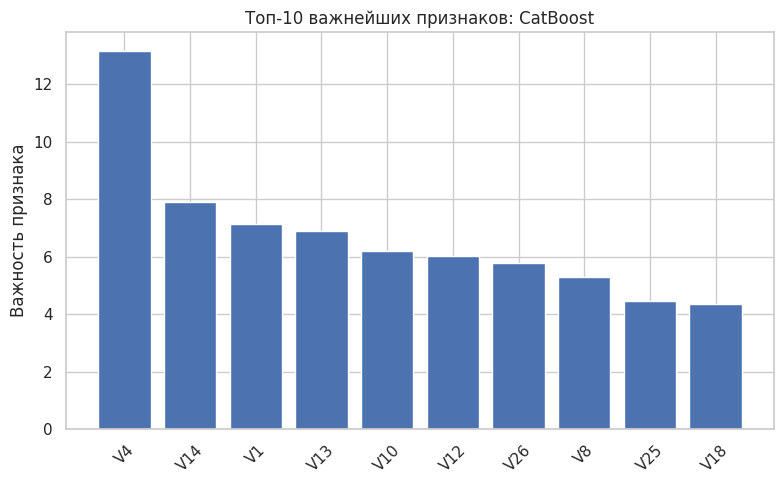

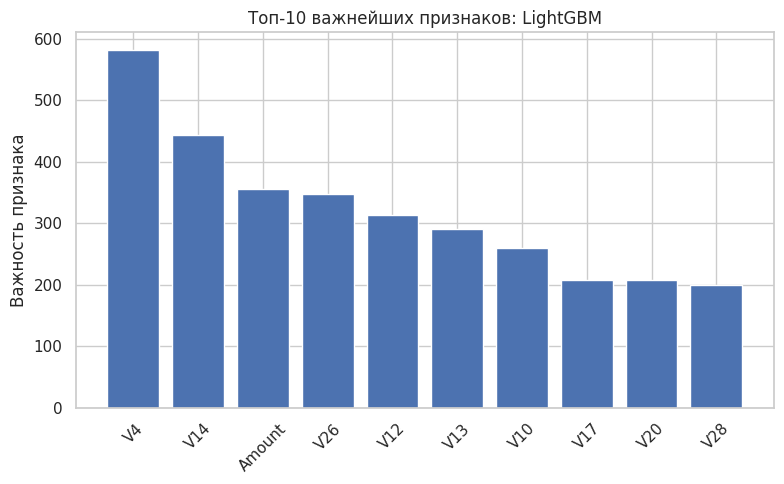

In [15]:
## Анализ важности признаков

import matplotlib.pyplot as plt
import numpy as np

def plot_feature_importance(model, model_name, feature_names, top_n=10):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:top_n]
        plt.figure(figsize=(8,5))
        plt.title(f"Топ-{top_n} важнейших признаков: {model_name}")
        plt.bar(range(top_n), importances[indices], align="center")
        plt.xticks(range(top_n), [feature_names[i] for i in indices], rotation=45)
        plt.ylabel("Важность признака")
        plt.tight_layout()
        plt.show()
    else:
        print(f"{model_name} не поддерживает feature_importances_")

# Список признаков
feature_names = df.drop('Class', axis=1).columns

# CatBoost
plot_feature_importance(models['CatBoost'], "CatBoost", feature_names)

# LightGBM
plot_feature_importance(models['LightGBM'], "LightGBM", feature_names)

In [16]:
## Оценка моделей и сравнительная таблица

results_df = evaluate_models(models, X_test, y_test)
results_df = results_df.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,CatBoost,0.9996,0.9630,0.7959,0.8715,0.9776
1,LightGBM,0.9994,0.9012,0.7449,0.8156,0.9699
2,ExtraTrees,0.9996,0.9535,0.8367,0.8913,0.9577
3,KNN,0.9995,0.9186,0.8061,0.8587,0.9437
4,DecisionTree,0.9991,0.7526,0.7449,0.7487,0.8722


In [17]:
## Определяем лучшую модель

best_model = results_df.iloc[0]
print(f"Лучшая модель: {best_model['Model']}, ROC-AUC: {best_model['ROC-AUC']}")

Лучшая модель: CatBoost, ROC-AUC: 0.9776


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


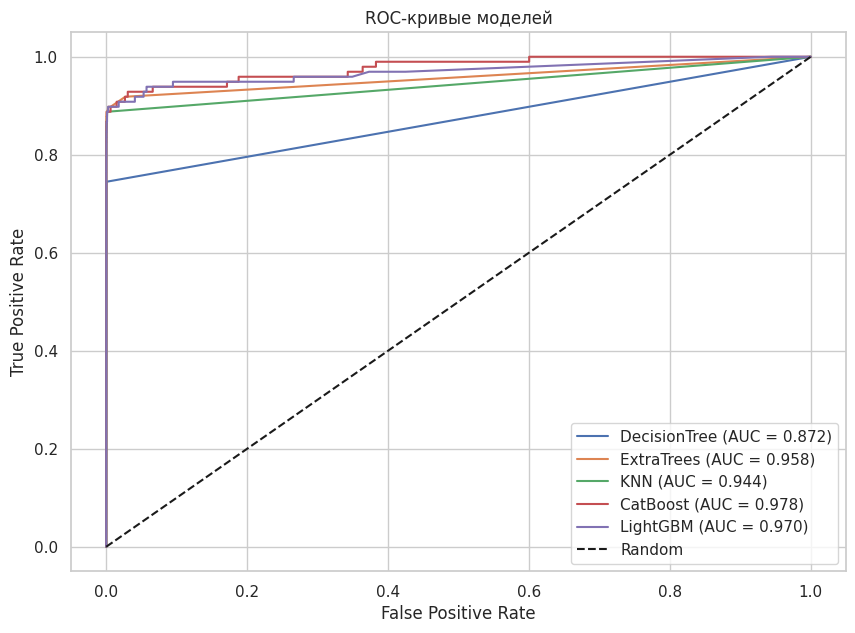

In [18]:
## ROC-кривые всех моделей

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC-кривые моделей')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

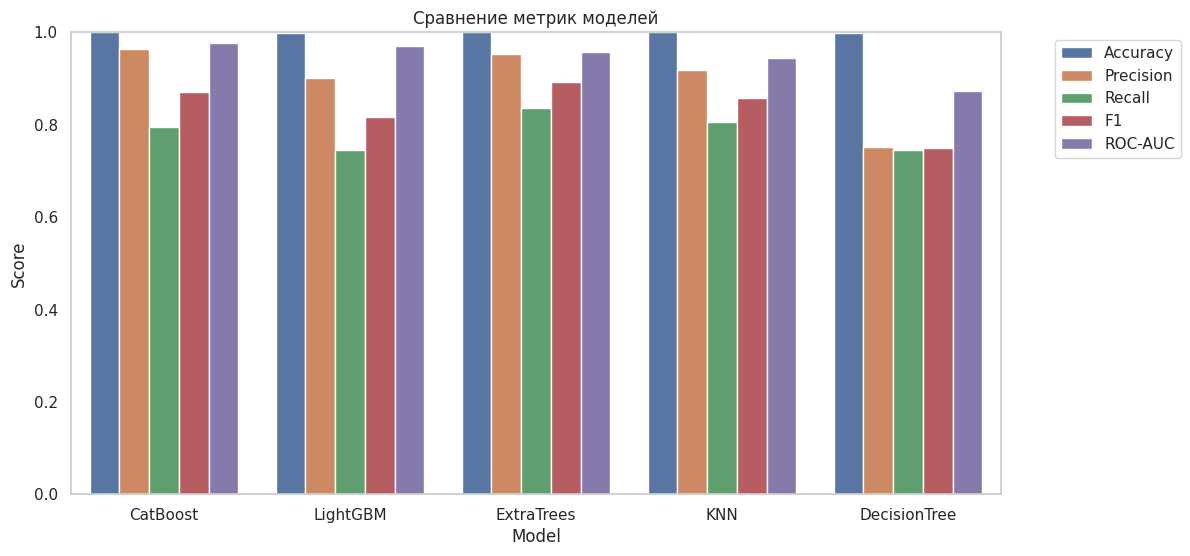

In [19]:
## Сравнение метрик моделей через barplot

import seaborn as sns

# Подготовим данные для графика
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
metrics_df = results_df.melt(id_vars=['Model'], value_vars=metrics, var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='Score', hue='Metric', data=metrics_df)
plt.title('Сравнение метрик моделей')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.show()